# Examen 1 LAE

---
Alan Jesús Hernández Soto \
Ing. Financiera \
Laboratorio de Aprendizaje Estadístico\
Examen

---

Importación de Librerias

In [83]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


Carga de Datos

In [ ]:
df = pd.read_csv('e01_datos.csv')
df.head()

,y,x1,x2,x3,grupo
0,13.643473,3.745401188473625,1.869147,6.363906,B
1,14.226813,9.50714306409916,6.743883,4.379466,A
2,15.312343,7.319939418114051,6.466175,5.648333,A
3,15.850062,5.986584841970366,3.012901,4.739714,A
4,15.477359,1.5601864044243652,1.443092,5.193992,B


Se identifica que cada columna tenga su tipo de variable correspondiente, y se corrige al igual que la columna categórica tenga valores únicos.

In [85]:
df.describe()

,y,x2,x3
count,183.000000,181.000000,182.000000
mean,14.053933,3.656675,5.054328
std,4.214684,2.596806,1.997665
min,4.000000,-2.194452,0.396158
25%,11.692237,1.603202,3.518048
50%,13.510425,3.463986,4.992027
75%,15.982460,5.689776,6.327197
max,42.000000,10.739239,11.157762


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       183 non-null    float64
 1   x1      183 non-null    object 
 2   x2      181 non-null    float64
 3   x3      182 non-null    float64
 4   grupo   182 non-null    object 
dtypes: float64(3), object(2)
memory usage: 7.3+ KB


In [87]:
df['x1'] = df['x1'].replace({',':'.'}, regex=True)
df['x1'] = df['x1'].astype(float)
df.describe()

,y,x1,x2,x3
count,183.000000,183.000000,181.000000,182.000000
mean,14.053933,4.722599,3.656675,5.054328
std,4.214684,2.959025,2.596806,1.997665
min,4.000000,0.055221,-2.194452,0.396158
25%,11.692237,2.172235,1.603202,3.518048
50%,13.510425,4.560700,3.463986,4.992027
75%,15.982460,7.293067,5.689776,6.327197
max,42.000000,9.868869,10.739239,11.157762


In [88]:
df['grupo'].unique()

array(['B', 'A', 'a', 'C', ' B ', 'grupo_c', 'AA', 'c', nan, 'b', 'D'],
      dtype=object)

In [89]:
df['grupo'] = df['grupo'].replace({'a':'A'})
df['grupo'] = df['grupo'].replace({'B ':'B'})
df['grupo'] = df['grupo'].replace({'grupo_c':'C'})
df['grupo'] = df['grupo'].replace({'AA':'A'})
df['grupo'] = df['grupo'].replace({'b':'B'})
df['grupo'] = df['grupo'].replace({' B':'B'})
df['grupo'] = df['grupo'].replace({'c':'C'})
df['grupo'] = df['grupo'].replace({' B ':'B'})
df['grupo'].unique()

array(['B', 'A', 'C', nan, 'D'], dtype=object)

In [90]:
df.isnull().sum()

y        0
x1       0
x2       2
x3       1
grupo    1
dtype: int64

In [91]:
df['x2'].fillna(df['x2'].median(), inplace=True)
df['x3'].fillna(df['x3'].median(), inplace=True)
df['grupo'].fillna(df['grupo'].mode()[0], inplace=True)
df.isnull().sum()


C:\Users\1\AppData\Local\Temp\ipykernel_28532\393309973.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['x2'].fillna(df['x2'].median(), inplace=True)
C:\Users\1\AppData\Local\Temp\ipykernel_28532\393309973.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

y        0
x1       0
x2       0
x3       0
grupo    0
dtype: int64

Regresión Lineal

In [103]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

num_cols = ['x1', 'x2', 'x3']
not_ordinal_cols = ['grupo']

not_ordinal_categories = ['A', 'B', 'C', 'D']

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

not_ordinal_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(categories=[not_ordinal_categories]))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('not_ordinal', not_ordinal_transformer, not_ordinal_cols)])

pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', LinearRegression())])

X = df.drop(columns=['y'])
y = df['y']

preprocessor.fit(X)
X_t = preprocessor.transform(X)

pipeline_lr.fit(X, y)
y_pred = pipeline_lr.predict(X)

print("R^2 score:", pipeline_lr.score(X, y))
print("Coefficients:", pipeline_lr.named_steps['model'].coef_)


R^2 score: 0.5951800163659999
Coefficients: [ 1.80246794  0.66599237  1.31325607  0.06277393  2.75874628 -2.15142877
 -0.67009144]


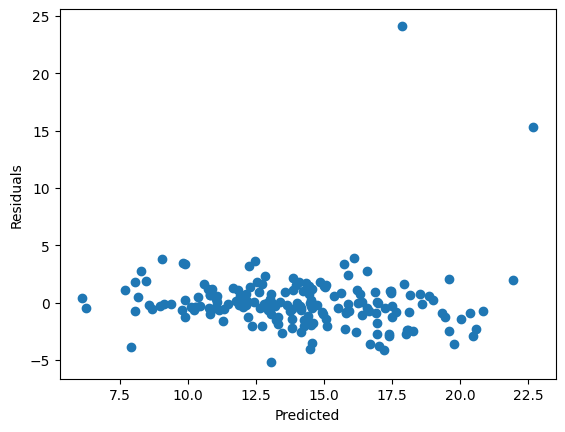

In [108]:
import matplotlib.pyplot as plt
e = y - y_pred
plt.scatter(y_pred, e)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()


Parece haber valores atípicos, mas parece que si hay linealidad.